In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(ggridges))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(colorspace))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donors <- c('C29', 'C37', 'C38', 'C39')
donor_order <- donors
donor_hexes <- c('#2851B0', '#C445B8', '#70373D', '#CFCF42')
names(donor_hexes) <- donor_order

tmp_order <- c('Start', 'Sendai', 'Skin', 'Inflamed', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#3CADBA', '#83E880', '#9C4F43',
                 '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')
names(clust_hexes) <- tmp_order

mod_order <- c('mCG', 'RNA', 'ATAC', '3C')
mod_hexes <- c('#8651CF', '#48B028', '#51ADCF', '#DEAE1F')
pmd_order <- c('PMDs', 'Non-PMDs')
pmd_hexes <- c('#BD2608', '#6FA2E3')
ips_dict <- c('IPS_main' = 'IPS_1', 'IPS_alt' = 'IPS_2')

c29_order <- c('Early_1', 'Early_2', 'Early_3', 'Early_4', 'Early_5',
               'Early_6', 'Early_7', 'Early_8', 'Transitional_1', 'Late_1', 'Late_2')
c37_order <- c('Early_1', 'Early_2', 'Early_3', 'Early_4', 'Early_5',
               'Early_6', 'Early_7', 'Transitional_1', 'Late_1')
c38_order <- c('Early_1', 'Early_2', 'Early_3', 'Early_4', 'Early_5',
               'Early_6', 'Early_7', 'Early_8', 'Early_9', 'Transitional_1', 'Late_1')
c39_order <- c('Early_1', 'Early_2', 'Early_3', 'Early_4', 'Early_5',
               'Early_6', 'Early_7', 'Early_8', 'Early_9', 'Early_10', 'Early_11',
               'Early_12', 'Early_13', 'Early_14', 'Early_15',
               'Transitional_1', 'Late_1', 'Late_2')
clust_list <- list(c29_order, c37_order, c38_order, c39_order)

c29_palette <- c('#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8')
c37_palette <- c('#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
                 '#ffff33', '#a65628', '#f781bf', '#999999')
c38_palette <- darken(c('#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854',
                        '#ffd92f', '#e5c494', '#b3b3b3', '#1b9e77', '#d95f02', '#7570b3'), amount = 0.3)
c39_palette <- darken(c('#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02',
                        '#a6761d', '#666666', '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c',
                        '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a'), amount = 0.3)
names(c29_palette) <- c29_order
names(c37_palette) <- c37_order
names(c38_palette) <- c38_order
names(c39_palette) <- c39_order
all_palettes <- list(c29_palette, c37_palette, c38_palette, c39_palette)

mean_se_manual <- function(x) {
  data.frame(
    y    = mean(x, na.rm = TRUE),
    ymin = mean(x, na.rm = TRUE) - sd(x, na.rm = TRUE) / sqrt(sum(!is.na(x))),
    ymax = mean(x, na.rm = TRUE) + sd(x, na.rm = TRUE) / sqrt(sum(!is.na(x)))
  )
}

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### A: quadruple-modality UMAPs by donor

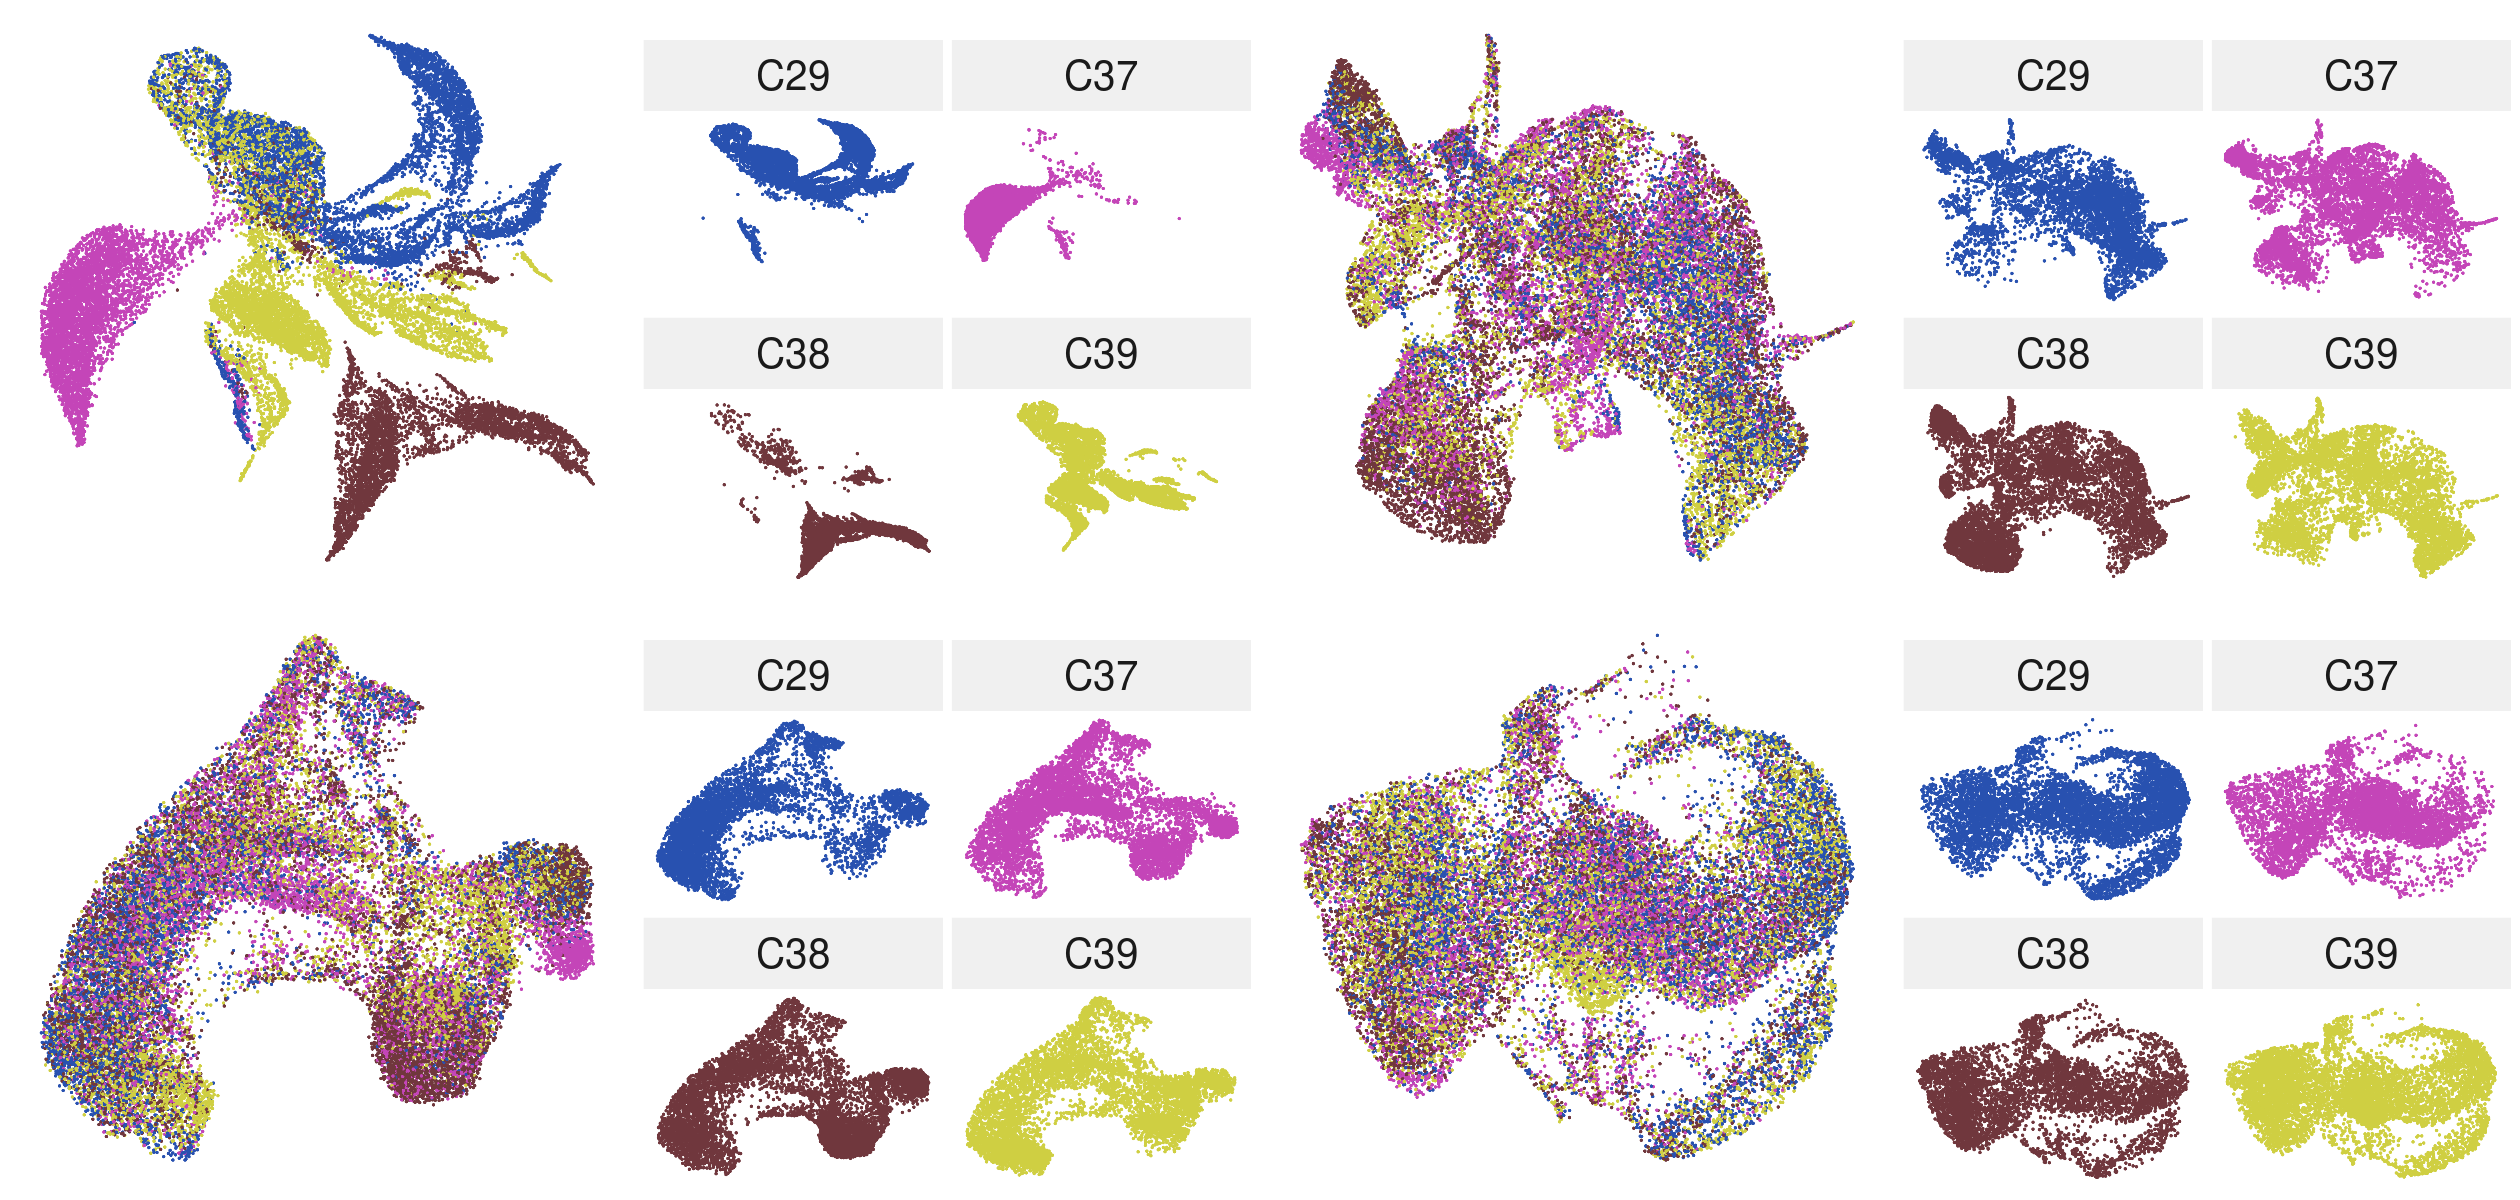

In [ ]:
mcg_path = paste0(projdir, '/csv/figure2/mcg_donor_umap.csv')
mcg_umap = as.data.frame(fread(mcg_path, sep='\t'))
mcg_umap$donor <- factor(mcg_umap$donor, levels=donor_order)

rna_path = paste0(projdir, '/csv/figure2/rna_donor_umap.csv')
rna_umap = as.data.frame(fread(rna_path, sep='\t'))
rna_umap$donor <- factor(rna_umap$donor, levels=donor_order)

atac_path = paste0(projdir, '/csv/figure2/atac_donor_umap.csv')
atac_umap = as.data.frame(fread(atac_path, sep='\t'))
atac_umap$donor <- factor(atac_umap$donor, levels=donor_order)

hic_path = paste0(projdir, '/csv/figure2/hic_donor_umap.csv')
hic_umap = as.data.frame(fread(hic_path, sep='\t'))
hic_umap$donor <- factor(hic_umap$donor, levels=donor_order)

plot_umap <- function(df) {
  ggplot(df, aes(x = umap0, y = umap1, color = donor)) +
  geom_point_rast(size = 0.1) +
    scale_color_manual(values = donor_hexes) +
    theme_bw() +
   base_theme +
    theme(
        axis.text.x = element_blank(),
        axis.text.y = element_blank(),
         axis.title.x = element_blank(),
        axis.title.y = element_blank())
}

plot_umap_facet <- function(df) {

  ggplot(df, aes(x = umap0, y = umap1, color = donor)) +
  geom_point_rast(size = 0.1) +
  base_theme +
    labs(x = "", y = "", title = '') +
    scale_color_manual(values = donor_hexes) +
    facet_wrap(~donor) +
    theme_bw() +
   base_theme +
    theme(
        axis.text.x = element_blank(),
        axis.text.y = element_blank(),
         axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        strip.text = element_text(size=24, margin = margin(t=10, b=10)),
        strip.background =  element_rect(fill="#F0F0F0", color=NA))

}

set.seed(1)
shuffled_mcg_umap <- mcg_umap[sample(nrow(mcg_umap)), ]
shuffled_rna_umap <- rna_umap[sample(nrow(rna_umap)), ]
shuffled_atac_umap <- atac_umap[sample(nrow(atac_umap)), ]
shuffled_hic_umap <- hic_umap[sample(nrow(hic_umap)), ]

reg_dfs <- list(
  "mCG" = shuffled_mcg_umap,
  "RNA" = shuffled_rna_umap,
  "ATAC" = shuffled_atac_umap,
  "Hi-C" = shuffled_hic_umap
)
reg_plots <- lapply(names(reg_dfs), function(name) {
  plot_umap(reg_dfs[[name]])
})

names(reg_plots) <- names(reg_dfs)

facet_dfs <- list(
  "mCG" = shuffled_mcg_umap,
  "RNA" = shuffled_rna_umap,
  "ATAC" = shuffled_atac_umap,
  "Hi-C" = shuffled_hic_umap
)
facet_plots <- lapply(names(facet_dfs), function(name) {
  plot_umap_facet(facet_dfs[[name]])
})

names(facet_plots) <- names(facet_dfs)

final <- list(reg_plots[['mCG']], facet_plots[['mCG']],
              reg_plots[['RNA']], facet_plots[['RNA']],
              reg_plots[['ATAC']], facet_plots[['ATAC']],
              reg_plots[['Hi-C']], facet_plots[['Hi-C']])

w = 21
h = 10
options(repr.plot.width=w, repr.plot.height=h)
p <- plot_grid(plotlist = final, nrow=2)
p

### B: nearest neighbors from the same donor

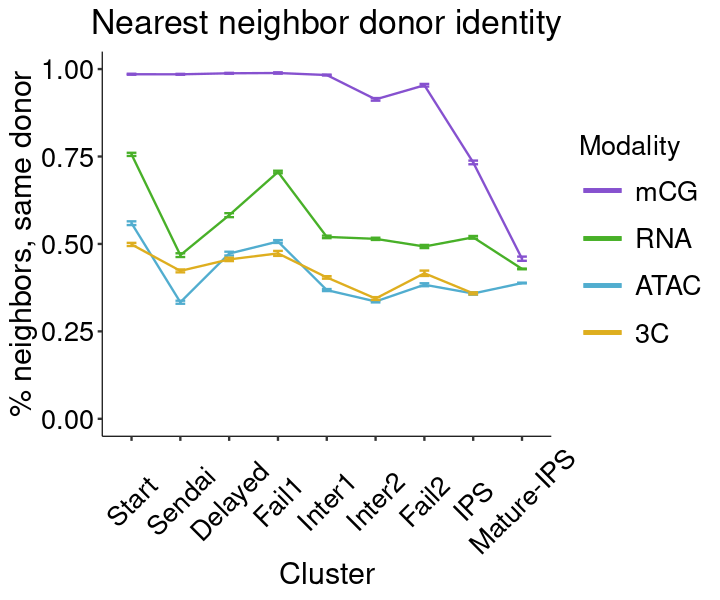

In [ ]:
merged_nn_path = paste0(projdir, '/csv/figure2/merged_nn.csv')
merged_nn = as.data.frame(fread(merged_nn_path, sep='\t'))
merged_nn$cluster <- factor(merged_nn$cluster, levels=tmp_order)
merged_nn$donor <- factor(merged_nn$donor, levels=donor_order)
merged_nn$mod <- factor(merged_nn$mod, levels=mod_order)

rna_nn_path = paste0(projdir, '/csv/figure2/pgp_mature_rna_nn.csv')
rna_nn = as.data.frame(fread(rna_nn_path, sep='\t'))

atac_nn_path = paste0(projdir, '/csv/figure2/pgp_mature_atac_nn.csv')
atac_nn = as.data.frame(fread(atac_nn_path, sep='\t'))

mcg_nn_path = paste0(projdir, '/csv/figure2/pgp_mature_mcg_nn.csv')
mcg_nn = as.data.frame(fread(mcg_nn_path, sep='\t'))
mcg_nn$cluster <- mcg_nn$batch
mcg_nn$cluster <- gsub('50-line', 'Mature-IPS', mcg_nn$cluster)

rna_nn$mod <- 'RNA'
atac_nn$mod <- 'ATAC'
mcg_nn$mod <- 'mCG'

select <- c('donor', 'cluster', 'donor_prop', 'mod')
final_rna <- rna_nn[select]
final_atac <- atac_nn[select]
final_mcg <- mcg_nn[select]
mature_nn <- rbind(final_rna, final_atac, final_mcg)

pgp_nn <- merged_nn[select]
final_nn <- rbind(pgp_nn, mature_nn)
mature_order <- c(tmp_order, 'Mature-IPS')
final_nn$cluster <- factor(final_nn$cluster, levels=mature_order)
final_nn$donor <- factor(final_nn$donor, levels=donor_order)
final_nn$mod <- factor(final_nn$mod, levels=mod_order)

w = 6
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(final_nn, aes(x = cluster, y = donor_prop, color = mod, group = mod)) +
  stat_summary(fun.data = mean_se_manual, geom = "line") +
  stat_summary(fun.data = mean_se_manual, geom = "errorbar", width = 0.2) +
  labs(x = "Cluster", y = "% neighbors, same donor",
       title = "Nearest neighbor donor identity", color = 'Modality') +
  scale_y_continuous(limits = c(0, 1)) +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_text(size=16,angle=45, color='black', vjust=0.5),
        axis.text.y = element_text(size=16,angle=0, color='black'),
        axis.title.x = element_text(size=18),
        axis.title.y = element_text(size=18),
         axis.line.x = element_line(linewidth=0.25),
         axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 16),
         legend.title = element_text(size=16),
        plot.title = element_text(size = 20, hjust = 0.5)) +
        scale_color_manual(values = mod_hexes) +
          guides(color = guide_legend(override.aes = list(linewidth = 1)),
            shape = guide_legend(title = ''))

### C: donor prediction F1-score

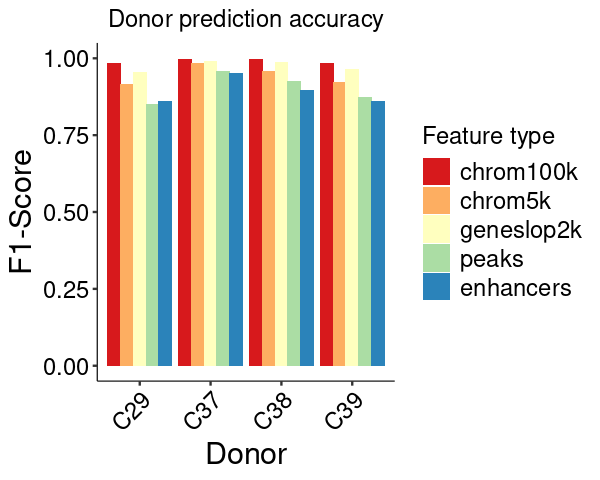

In [ ]:
var_order <- c('chrom100k','chrom5k','geneslop2k','peaks','dmrs','enhancers')
donor_f1_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct_mcg_donor_feature_f1.csv'
donor_f1 <- as.data.frame(fread(donor_f1_path))
donor_f1$var_dim <- factor(donor_f1$var_dim, levels=var_order)
mask <- !is.na(donor_f1$var_dim)
donor_f1 <- donor_f1[mask,]
mask <- donor_f1$var_dim != 'dmrs'
donor_f1 <- donor_f1[mask,]

w = 5
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(donor_f1, aes(x = variable, y = value, fill = var_dim)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(x = "Donor",y = "F1-Score",title = 'Donor prediction accuracy',fill = "Feature type") +
  scale_y_continuous(limits = c(0, 1)) +
  scale_fill_brewer(palette='Spectral') +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 14, color='black'),
    axis.text.y = element_text(size = 14, color='black'),
    plot.title = element_text(size = 14, hjust = 0.5, color='black'),
    axis.title = element_text(size = 18),
     axis.line.x = element_line(linewidth=0.25),
     axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
      legend.text = element_text(size=14),
    legend.position = "right",
    legend.title = element_text(size=14)
  )

### D: global mCG per cluster/donor

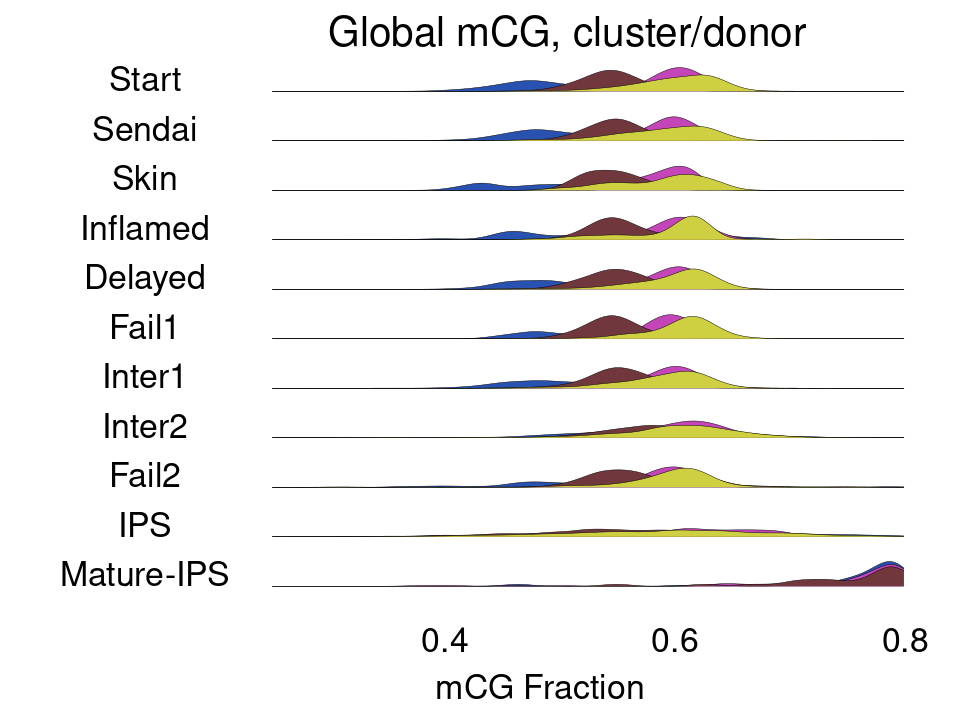

In [ ]:
indir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'
mature <- as.data.frame(fread(paste0(indir, '/csv/figure2/snmct_mature_ips_mcg.csv'), sep='\t'))
colnames(mature)[colnames(mature) == 'donor'] <- 'line'
mature$cluster <- 'Mature-IPS'
mature <- mature[,-1]

indir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'
meta <- as.data.frame(fread(paste0(indir, '/csv/figure2/cluster_donor_mcg.csv'), sep='\t'))
mask <- !is.na(meta$cluster)
final_meta <- meta[mask,]
final_meta <- final_meta[,-1]

to_plot <- rbind(final_meta, mature)
mature_order <- c(tmp_order, 'Mature-IPS')
cat_order <- rev(mature_order)
to_plot$cluster <- factor(to_plot$cluster, levels = cat_order)

w = 8
h = 6
options(repr.plot.width=w, repr.plot.height=h)

ggplot(to_plot, aes(x = DNA_mCGfrac, y = cluster, fill = line)) +
geom_density_ridges(scale = 0.5, alpha = 1.0, size=0.1) +
scale_x_continuous(limits = c(0.25, 0.8)) +
    scale_fill_manual(values=donor_hexes) +
  labs(x = "mCG Fraction", y = "", title = 'Global mCG, cluster/donor') +
  theme_ridges()  +
  base_theme +
  theme(
      axis.title.x = element_text(size = 20, hjust=0.4),
      axis.title.y = element_text(size = 20, hjust=0.5),
      axis.text.x = element_text(size = 20, hjust=0.5),
      axis.text.y = element_text(size = 20, hjust=0.5),
      plot.title = element_text(size = 24, hjust=0.4, face='plain'),
        legend.position = 'none'
      )

### E: between-donor variance inside/outside features

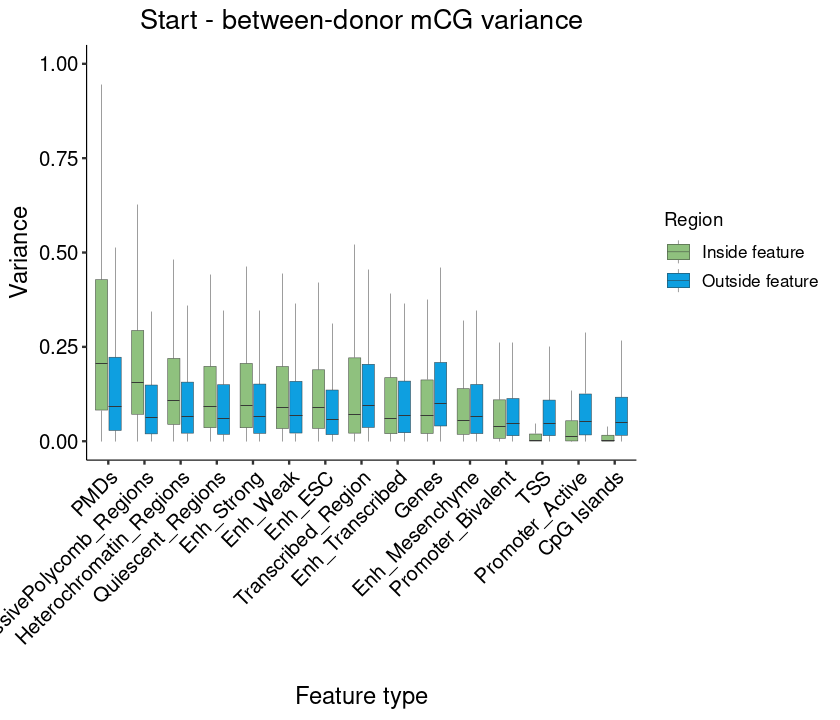

In [ ]:
annot_path = paste0(projdir, '/csv/figure2/pgp_feature_var.csv.gz')
annot = as.data.frame(fread(annot_path, sep='\t'))

annot$feature <- gsub('pmd', 'PMDs', annot$feature)
annot$feature <- gsub('cpg-island', 'CpG Islands', annot$feature)
annot$feature <- gsub('gene', 'Genes', annot$feature)

rename_dict <- c(
  "in_feature" = "Inside feature",
  "outside_feature" = "Outside feature")
annot$variable <- rename_dict[annot$variable]
feature_order <- c('Inside feature', 'Outside feature')
annot$variable <- factor(annot$variable, levels=feature_order)

feature_order <- c("PMDs", "RepressivePolycomb_Regions", "Heterochromatin_Regions",
                   "Quiescent_Regions", "Enh_Strong", "Enh_Weak", "Enh_ESC",
                  "Transcribed_Region", "Enh_Transcribed","Genes",
                  "Enh_Mesenchyme", "Promoter_Bivalent", "TSS", "Promoter_Active", "CpG Islands")
annot$feature <- factor(annot$feature, levels=feature_order)
mask <- !is.na(annot$feature)
annot <- annot[mask,]

feat_hexes <- c('#8FC17E', '#0E9FE0')

w = 7
h = 6
options(repr.plot.width=w, repr.plot.height=h)

ggplot(annot, aes(x = feature, y = value, fill = variable)) +
    geom_boxplot(outlier.size = 0.3, outlier.shape = NA, linewidth=0.1) +
    labs(x = "Feature type", y = "Variance", fill = "Region",
         title = 'Start - between-donor mCG variance') +
    coord_cartesian(ylim = c(0, 1)) +
  scale_fill_manual(values=feat_hexes) +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, color='black'),
    axis.text.y = element_text(size = 12, color='black'),
    axis.title = element_text(size = 14),
    plot.title = element_text(size=16, hjust=0.5),
     axis.line.x = element_line(linewidth=0.25),
     axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
    legend.text = element_text(size=10),
    legend.position = "right"
  )

### G: PMD metagene, Start / early-IPS / mature-IPS

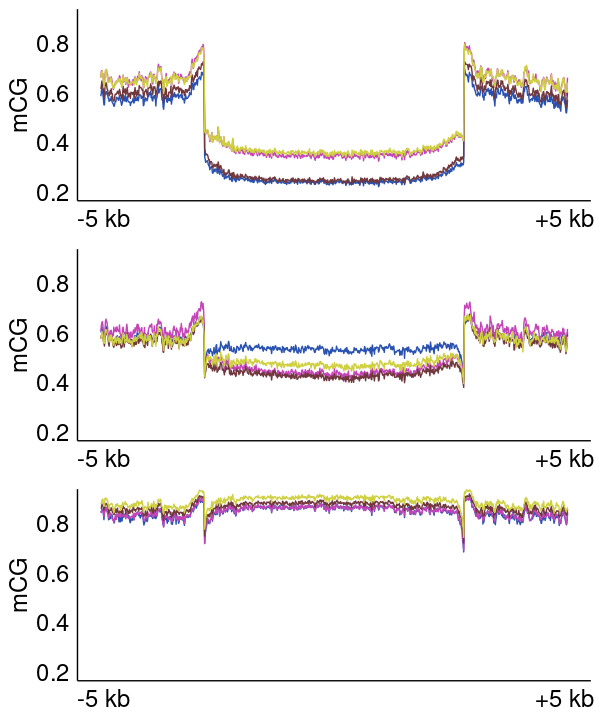

In [ ]:
pmd_flank_path = paste0(projdir, '/csv/figure3/pmds_flank_metagene.csv')
pmd_flank = as.data.frame(fread(pmd_flank_path, sep='\t'))
pmd_flank$donor <- factor(pmd_flank$donor, levels=donor_order)
pmd_flank$cluster <- factor(pmd_flank$cluster, levels=tmp_order)
colnames(pmd_flank) <- c('V1', 'mCG', 'tmp', 'sample', 'cluster', 'donor')

mature_flank_path = paste0(projdir, '/csv/figure3/50_line_pmds_flank_metagene.csv')
mature_flank = as.data.frame(fread(mature_flank_path, sep='\t'))
mature_flank$donor <- factor(mature_flank$donor, levels=donor_order)
colnames(mature_flank) <- c('V1', 'mCG', 'tmp', 'sample', 'donor', 'cluster')
mask <- mature_flank$cluster == 'IPS'
mature_flank <- mature_flank[mask,]
mature_flank$cluster <- gsub('IPS', 'Mature-IPS', mature_flank$cluster)

final_flank <- rbind(pmd_flank, mature_flank)
final_flank$donor <- factor(final_flank$donor, levels=donor_order)

slack = 6
tmp_breaks <- c(min(final_flank$tmp) + slack, max(final_flank$tmp) - slack)

plot_pmds <- function(tmp_flank) {
    ggplot(tmp_flank, aes(x = tmp, y = mCG, color = donor, group = donor)) +
        geom_line(linewidth=0.3) +
      coord_cartesian(ylim = c(0.2, 0.9)) +
        scale_x_continuous(breaks = tmp_breaks, labels = c("-5 kb", "+5 kb")) +
      theme_bw() +
      base_theme +
       theme(axis.text.x = element_text(size = 14,color='black'),
            axis.text.y = element_text(size = 14,color='black'),
             axis.title.x = element_blank(),
            axis.title.y = element_text(size = 14,color='black'),
             axis.line.x = element_line(linewidth=0.3),
             axis.line.y = element_line(linewidth=0.3)) +
            scale_color_manual(values = donor_hexes)
}

plot_list <- list()
tmp_plot <- c('Start', 'IPS', 'Mature-IPS')
for (i in seq_along(tmp_plot)) {
    s <- tmp_plot[i]
    tmp_flank <- final_flank[final_flank$cluster == s,]
    plot_list[[i]] <- plot_pmds(tmp_flank)
}

w = 5
h = 6
options(repr.plot.width=w, repr.plot.height=h)

p <- plot_grid(plotlist=plot_list, nrow=3)
p

### H: A/B compartments overlapping PMDs

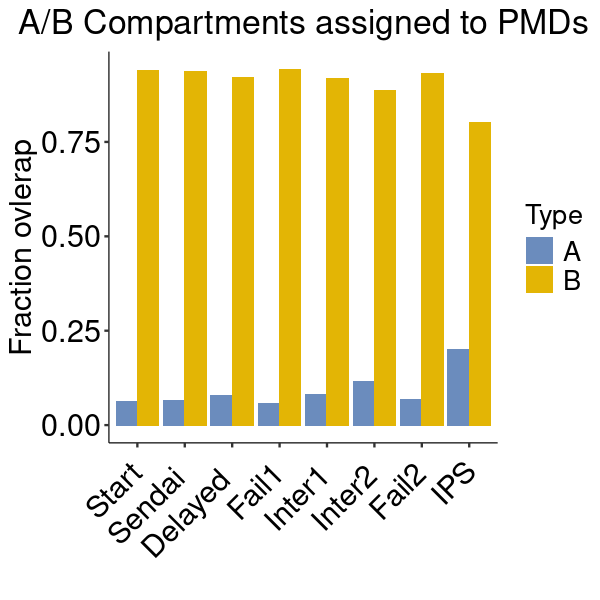

In [ ]:
pmds_comps_path = paste0(projdir, '/csv/figure2/3c_b_comps_pmds_concordance.csv')
pmds_comps = read.csv(pmds_comps_path, sep='\t')
pmds_comps$cluster <- factor(pmds_comps$cluster, levels=tmp_order)

comps_order <- c('A', 'B')
comps_palette <- c("#6B8CBD", "#E3B505")

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pmds_comps, aes(x = cluster, y = value, fill = variable)) +
    geom_bar(stat = "identity", position='dodge') +
  labs(x = "",y = "Fraction ovlerap",
       title = "A/B Compartments assigned to PMDs", fill='Type') +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 18, angle = 45, hjust = 1.2, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title = element_text(size = 18),
    plot.title = element_text(size = 20, hjust = 0.5),
     axis.line.x = element_line(linewidth=0.25),
     axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
      legend.text = element_text(size=16),
    legend.title = element_text(size=16),
    legend.position = "right"
  ) +
  scale_fill_manual(values=comps_palette)

### I: PMD methylation per cluster

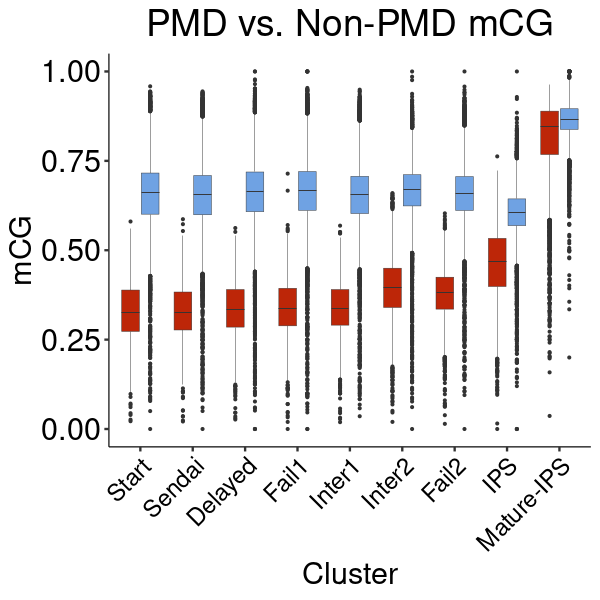

In [ ]:
pmd_path = paste0(projdir, '/csv/figure2/pmds_comp_rna_cluster_donor_mcg.csv')
pmd_mcg = as.data.frame(fread(pmd_path, sep='\t'))
pmd_mcg$donor <- factor(pmd_mcg$donor, levels=donor_order)
pmd_mcg$cluster <- factor(pmd_mcg$cluster, levels=tmp_order)
pmd_mcg$type <- factor(pmd_mcg$type, levels=pmd_order)

mature_path = paste0(projdir, '/csv/figure3/50_line_pmds_comp_rna_cluster_donor_mcg.csv')
mature_mcg = as.data.frame(fread(mature_path, sep='\t'))
mature_mcg$donor <- factor(mature_mcg$donor, levels=donor_order)
mature_mcg$type <- factor(mature_mcg$type, levels=pmd_order)
mature_mcg$cluster <- gsub('IPS', 'Mature-IPS', mature_mcg$cluster)

mature_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS', 'Mature-IPS')
merged_mcg <- rbind(pmd_mcg, mature_mcg)
merged_mcg$cluster <- factor(merged_mcg$cluster, levels=mature_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(merged_mcg, aes(x = cluster, y = value, fill = type)) +
    geom_boxplot(outlier.size = 0.1, linewidth = 0.1) +
    labs(x = "Cluster", y = "mCG", fill = "Region",
         title = 'PMD vs. Non-PMD mCG') +
  scale_fill_manual(values=pmd_hexes) +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 14, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title = element_text(size = 18),
    plot.title = element_text(size=22, hjust=0.5),
     axis.line.x = element_line(linewidth=0.25),
     axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
      legend.text = element_text(size=14),
  )

### J: per-donor mC clusters, day 0 mC clusters, RNA clusters

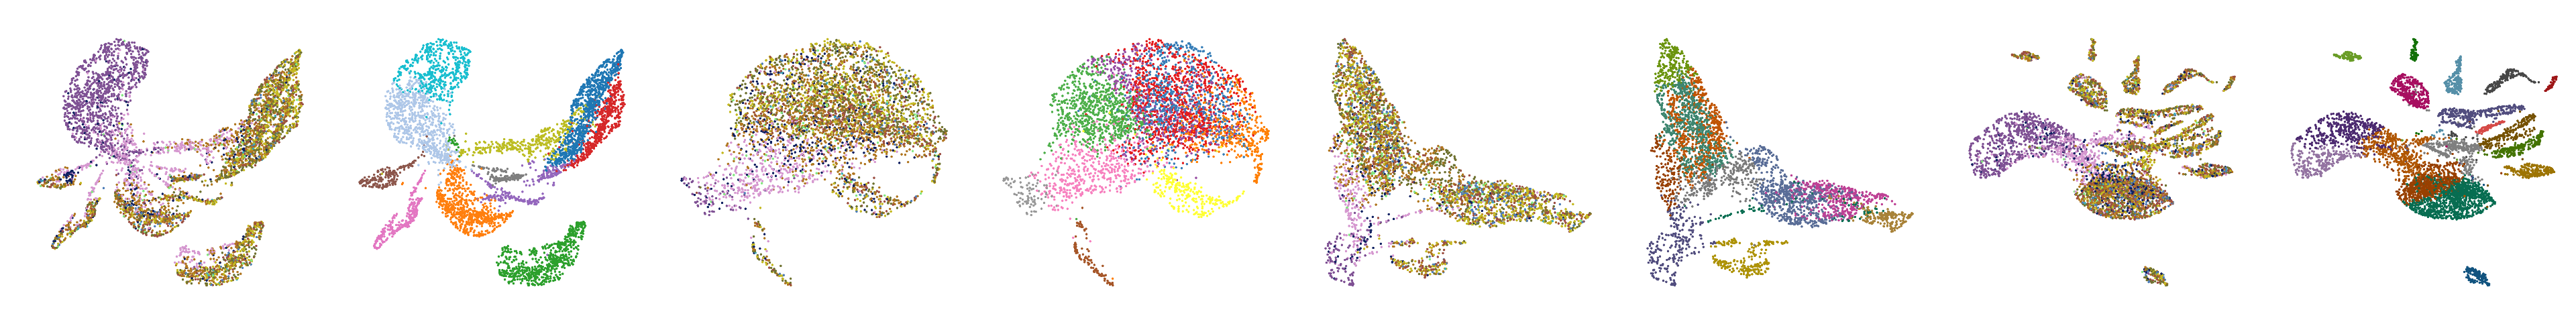

In [ ]:
mcg_umap_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct.chrom100k.per_donor.umap.csv'
mcg_umap <- as.data.frame(fread(mcg_umap_path))
mcg_umap$cluster <- factor(mcg_umap$cluster, levels=tmp_order)
mcg_umap$leiden <- gsub('Fibro', 'Early', mcg_umap$leiden)
mcg_umap$leiden <- gsub('Inter', 'Transitional', mcg_umap$leiden)
mcg_umap$leiden <- gsub('IPS', 'Late', mcg_umap$leiden)
mask <- !is.na(mcg_umap$cluster)
mcg_umap <- mcg_umap[mask,]

plot_umap_pair <- function(donor_name, mcg_umap_df, mc_palette) {

  tmp_df <- mcg_umap_df %>% filter(line == donor_name)
  shuffled_df <- tmp_df[sample(nrow(tmp_df)), ]

  p1 <- ggplot(shuffled_df, aes(x = umap0, y = umap1, color = leiden)) +
  geom_point_rast(size = 0.1) +
    labs(x = "", y = "", title = '') +
    theme_minimal() +
    base_theme +
    theme(
        axis.text.x = element_blank(),
      axis.text.y = element_blank()) +
    scale_color_manual(values = mc_palette)

  p2 <- ggplot(shuffled_df, aes(x = umap0, y = umap1, color = cluster)) +
  geom_point_rast(size = 0.1) +
    labs(x = "", y = "", title = '',) +
    theme_minimal() +
    base_theme +
    theme(
        axis.text.x = element_blank(),
      axis.text.y = element_blank()) +
    scale_color_manual(values = clust_hexes)

  return(list(leiden_plot = p1, cluster_plot = p2))
}

mc_plots <- list()
rna_plots <- list()

for (i in seq_along(donors)) {
  d <- donors[i]
  tmp_mcg_palette <- all_palettes[[i]]

  plots <- plot_umap_pair(d, mcg_umap, tmp_mcg_palette)
  mc_plots[[d]] <- plots$leiden_plot
  rna_plots[[d]]   <- plots$cluster_plot
}

final <- list(rna_plots[['C29']], mc_plots[['C29']],
              rna_plots[['C37']], mc_plots[['C37']],
              rna_plots[['C38']], mc_plots[['C38']],
              rna_plots[['C39']], mc_plots[['C39']])

w = 32
h = 4
options(repr.plot.width=w, repr.plot.height=h)

combined_plot <- plot_grid(plotlist = final, nrow=1)
print(combined_plot)

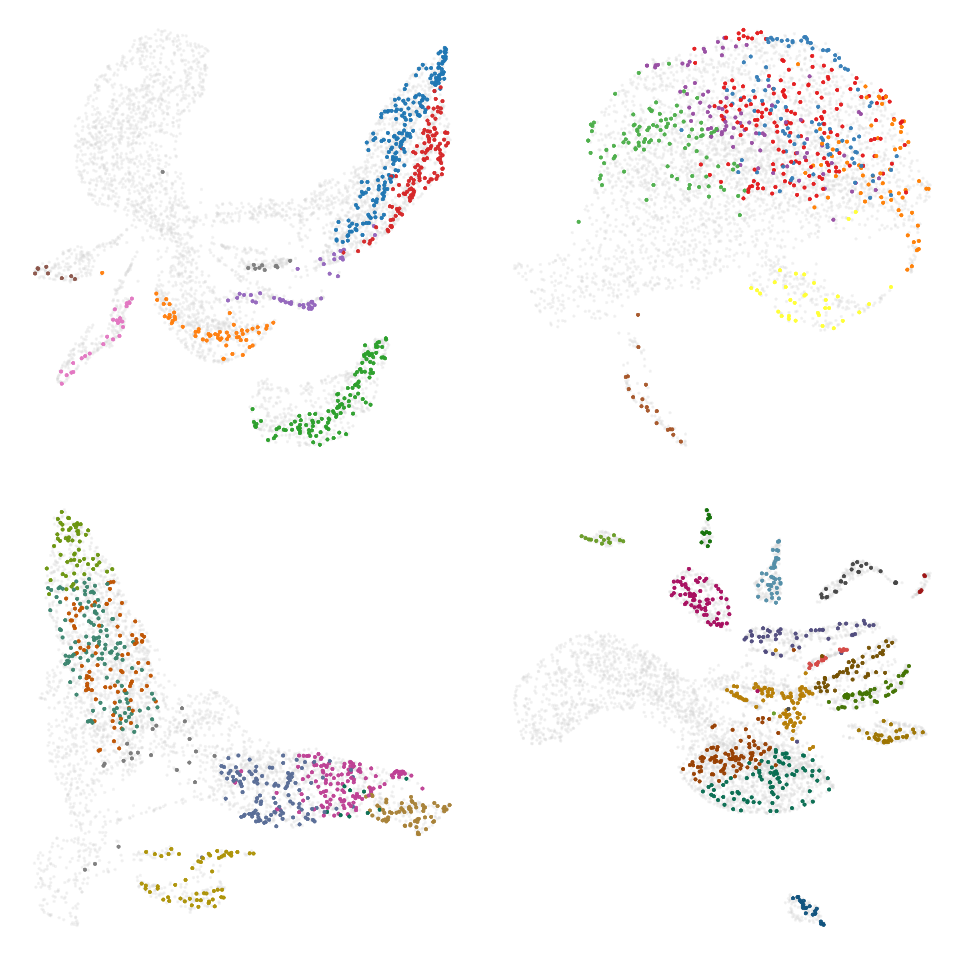

In [ ]:
tmp_umap_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct.chrom100k.per_donor.umap.csv'
tmp_umap <- as.data.frame(fread(tmp_umap_path))
tmp_umap$cluster <- factor(tmp_umap$cluster, levels=tmp_order)
mask <- !is.na(tmp_umap$cluster)
tmp_umap <- tmp_umap[mask,]

mcg_umap_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct_mcg_donor_day0_umap.csv'
mcg_umap <- as.data.frame(fread(mcg_umap_path))
mcg_umap$time <- factor(mcg_umap$time)
mcg_umap$donor <- factor(mcg_umap$donor, levels=donors)
mcg_umap$time_highlight <- ifelse(mcg_umap$time == 0, mcg_umap$mc_cluster, 'other')
mcg_umap$plot_col <- paste0(mcg_umap$donor, '_', mcg_umap$time_highlight)
mask <- rownames(mcg_umap) %in% rownames(tmp_umap)
mcg_umap <- mcg_umap[mask,]

plot_day0_umap <- function(df, d, tmp_palette) {
  mask = df$donor == d
  tmp_df <- df[mask,]
  grey_df <- tmp_df[tmp_df$time_highlight == 'other', ]
  highlight_df <- tmp_df[tmp_df$time_highlight != 'other', ]

  ggplot(tmp_df, aes(x = umap0, y = umap1, color = time_highlight)) +
    geom_point_rast(data = grey_df, size = 0.1, alpha = 0.2) +
    geom_point_rast(data = highlight_df, size = 0.3, alpha = 0.9) +
    scale_color_manual(values = tmp_palette) +
    theme_bw() +
    base_theme +
    theme(
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_blank(),
        axis.text.y = element_blank())
}

plot_list <- list()
for (i in seq_along(donors)) {
    d <- donors[i]
    tmp_palette <- c(all_palettes[[i]], 'other' = '#D3D3D3')
    p <- plot_day0_umap(mcg_umap, d, tmp_palette)
    plot_list[[i]] <- p
}

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)

combined_plot <- plot_grid(plotlist = plot_list, ncol = 2)
print(combined_plot)

### L: RNA cluster composition of mC clusters

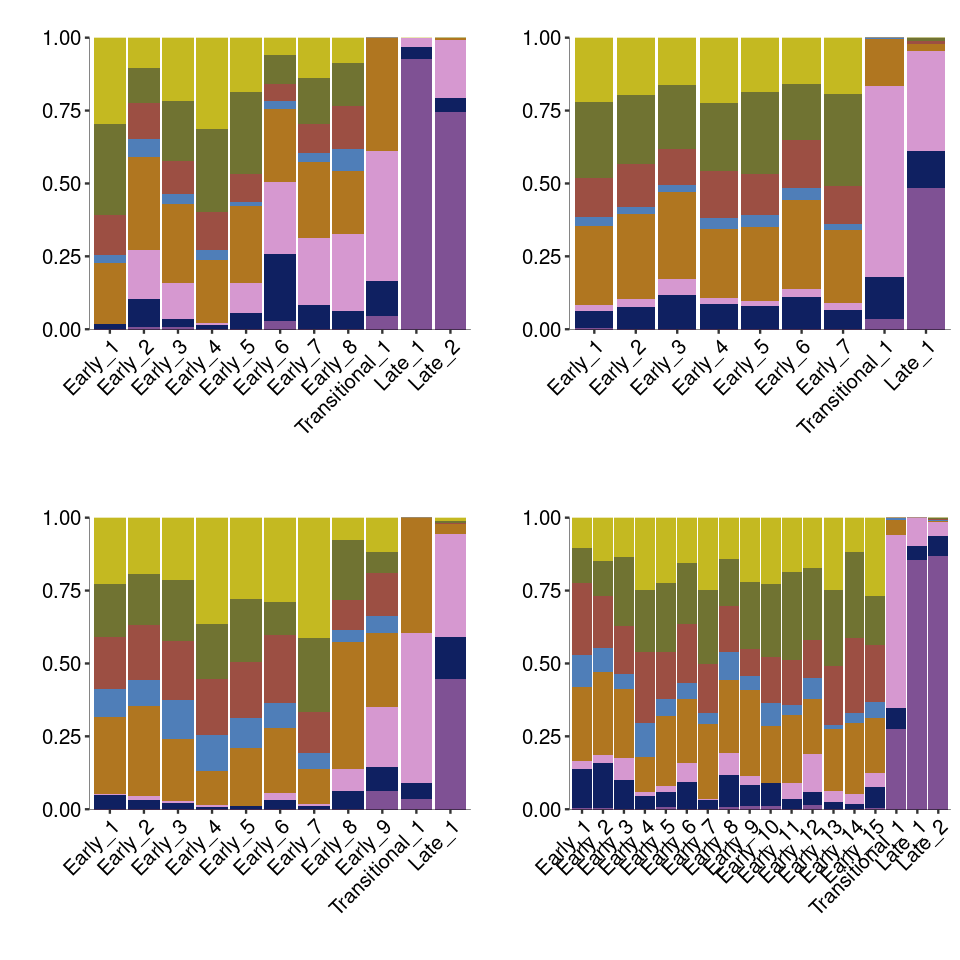

In [ ]:
rna_order <- c('Start', 'Sendai', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
rna_hexes <- c('#C4B921', '#707332', '#9C4F43',
                 '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')

mc_rna_dist_path <- paste0(projdir, '/csv/figure2/snmct_rna_mc_cluster_props.csv')
mc_rna_dist <- as.data.frame(fread(mc_rna_dist_path))

make_plot <- function(tmp_df) {

    ggplot(tmp_df, aes(x = cluster, y = prop, fill = state)) +
      geom_bar(stat = "identity") +
      labs(x = "",y = "",title = '',fill = "RNA cluster") +
      scale_y_continuous(limits = c(0, 1), expand = c(0, 0)) +
      theme_bw() +
      theme(
        axis.text.x = element_text(size = 12, angle = 45, hjust = 1, color='black'),
        axis.text.y = element_text(size = 12, color='black'),
        plot.title = element_text(size = 12, hjust = 0.5, color='black'),
        axis.title = element_text(size = 18),
         axis.line.x = element_line(linewidth=0.1),
         axis.line.y = element_line(linewidth=0.1),
         panel.border = element_blank(),
         panel.grid = element_blank(),
         panel.background = element_blank(),
         plot.background  = element_blank(),
        legend.position = "none"
      ) +
      scale_fill_manual(values=rna_hexes)
}

mc_rna_dist$V1 <- gsub('Fibro', 'Early', mc_rna_dist$V1)
mc_rna_dist$V1 <- gsub('Inter', 'Transitional', mc_rna_dist$V1)
mc_rna_dist$V1 <- gsub('IPS', 'Late', mc_rna_dist$V1)

plots <- list()

for (i in seq_along(donors)) {
    d <- donors[i]
    mask <- mc_rna_dist$donor == d
    tmp_dist <- mc_rna_dist[mask,]
    tmp_dist <- tmp_dist[,-ncol(tmp_dist)]
    rownames(tmp_dist) <- tmp_dist$V1
    tmp_dist <- tmp_dist[,-1]
    tmp_dist$cluster <- rownames(tmp_dist)
    df_long <- tmp_dist %>% pivot_longer(-cluster, names_to = "state", values_to = "prop")
    df_long$state <- factor(df_long$state, levels=rna_order)
    df_long <- df_long %>% mutate(cluster = recode(cluster, !!!ips_dict))

    mc_order <- clust_list[[i]]
    df_long$cluster <- factor(df_long$cluster, levels=mc_order)
    plots[[i]] = make_plot(df_long)
}

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)

p <- plot_grid(plotlist = plots, nrow=2)
p

### M: log2FC of Inter2/Fail1/Fail2 per mC cluster

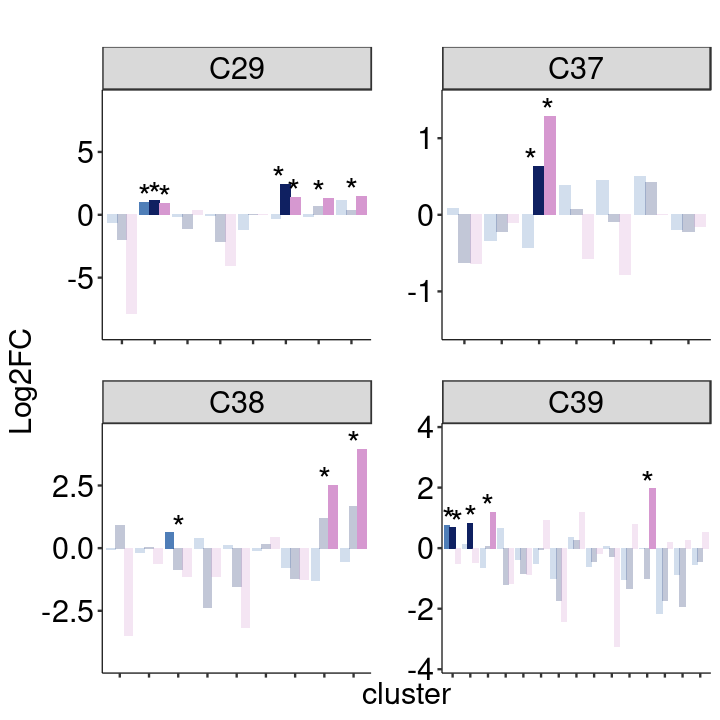

In [ ]:
fisher_rna_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct_donor_fibro_fisher_fail_inter.csv'
fisher_rna <- as.data.frame(fread(fisher_rna_path))
fisher_rna$cluster <- gsub('Fibro', 'Early', fisher_rna$cluster)

fisher_order <- c('Fail1', 'Fail2', 'Inter2')

fisher_rna$rna_cluster <- factor(fisher_rna$rna_cluster, levels=fisher_order)
mask <- !is.na(fisher_rna$rna_cluster)
fisher_rna <- fisher_rna[mask,]

fibro_order <- unique(fisher_rna$mc_cluster)

donor_prefix <- sub("_Fibro_[0-9]+$", "", fibro_order)
fibro_num <- as.numeric(sub(".*_Fibro_", "", fibro_order))

fibro_order <- fibro_order[order(donor_prefix, fibro_num)]
fisher_rna$mc_cluster <- factor(fisher_rna$mc_cluster, levels=fibro_order)

fisher_rna <- fisher_rna %>%
  arrange(match(mc_cluster, fibro_order)) %>%
  mutate(cluster_uniq = paste(cluster, donor, sep = "___")) %>%
  mutate(cluster_uniq = factor(cluster_uniq, levels = unique(cluster_uniq)))

fisher_rna$cluster_uniq <- factor(fisher_rna$cluster_uniq, levels = unique(fisher_rna$cluster_uniq))

fisher_rna <- fisher_rna %>%
  mutate(sig = ifelse(neglog10p > 2, "Significant", "NS"))

summary_stats <- fisher_rna %>%
  group_by(donor, cluster_uniq, rna_cluster) %>%
  summarise(
    mean_val = mean(log2fc, na.rm = TRUE),
    se_val = sd(log2fc, na.rm = TRUE) / sqrt(n()),
    sig = first(sig),
    .groups = "drop"
  ) %>%
  mutate(
    bar_top = mean_val + ifelse(is.na(se_val), 0, se_val),
    bar_bottom = mean_val - ifelse(is.na(se_val), 0, se_val)
  )

donor_ranges <- summary_stats %>%
  group_by(donor) %>%
  summarise(
    y_extreme = max(abs(c(bar_top, bar_bottom)), na.rm = TRUE) * 1.15
  ) %>%
  mutate(y_max = y_extreme, y_min = -y_extreme) %>%
  select(donor, y_min, y_max)

blank_data <- donor_ranges %>%
  tidyr::pivot_longer(cols = c(y_min, y_max), values_to = "log2fc") %>%
  select(donor, log2fc)

star_data <- summary_stats %>%
  filter(sig == "Significant") %>%
  left_join(donor_ranges, by = "donor") %>%
  mutate(
    star_y = ifelse(mean_val >= 0, bar_top + 0.05 * y_max, bar_bottom - 0.05 * y_max)
  )

p2 <- ggplot(fisher_rna, aes(x = cluster_uniq, y = log2fc, fill = rna_cluster, alpha = sig)) +
  stat_summary(fun = mean, geom = "bar", position = position_dodge(width = 0.9)) +
  stat_summary(fun.data = mean_se, geom = "errorbar",
               position = position_dodge(width = 0.9), width = 0.2) +
  geom_blank(data = blank_data, aes(x = 1, y = log2fc), inherit.aes = FALSE) +
  geom_text(
    data = star_data,
    aes(x = cluster_uniq, y = star_y, group = rna_cluster),
    label = "*", size = 7, color = "black",
    position = position_dodge(width = 0.9),
    inherit.aes = FALSE
  ) +
  scale_x_discrete(labels = function(x) sub("___.*$", "", x)) +
  facet_wrap(~ donor, nrow = 2, ncol = 2, scales = "free") +
  labs(x = "cluster", y = "Log2FC", title = "") +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_blank(),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title = element_text(size = 18),
    plot.title = element_text(size = 18, hjust = 0.5),
    axis.line.x = element_line(linewidth=0.25),
    axis.line.y = element_line(linewidth=0.25),
    axis.ticks.x = element_line(linewidth=0.5),
    axis.ticks.y = element_line(linewidth=0.5),
    strip.text = element_text(color='black', size=18),
    panel.spacing = unit(1.5, "lines")
  ) +
  scale_fill_manual(values = clust_hexes) +
  scale_alpha_manual(values = c("Significant" = 1, "NS" = 0.25), guide = "none")

w = 6
h = 6
options(repr.plot.width=w, repr.plot.height=h)
p2

In [ ]:
sessionInfo()

In [ ]:
Sys.time()